In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('houses.csv')

df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,22.19
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,53.80
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,18.00
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,60.40
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,51.00


In [7]:
print(df.shape)
print(df.info())

(1000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       999 non-null    float64
 1   bathrooms      999 non-null    float64
 2   sqft_living    999 non-null    float64
 3   sqft_lot       999 non-null    float64
 4   floors         999 non-null    float64
 5   waterfront     999 non-null    float64
 6   view           999 non-null    float64
 7   condition      999 non-null    float64
 8   grade          999 non-null    float64
 9   sqft_above     999 non-null    float64
 10  sqft_basement  999 non-null    float64
 11  yr_built       999 non-null    float64
 12  yr_renovated   999 non-null    float64
 13  zipcode        999 non-null    float64
 14  lat            999 non-null    float64
 15  long           999 non-null    float64
 16  sqft_living15  999 non-null    float64
 17  price          999 non-null    float64
dty

In [8]:
print(df.isna().sum())

bedrooms         1
bathrooms        1
sqft_living      1
sqft_lot         1
floors           1
waterfront       1
view             1
condition        1
grade            1
sqft_above       1
sqft_basement    1
yr_built         1
yr_renovated     1
zipcode          1
lat              1
long             1
sqft_living15    1
price            1
dtype: int64


In [9]:
df = df.dropna()

In [10]:
df.duplicated().sum()

0

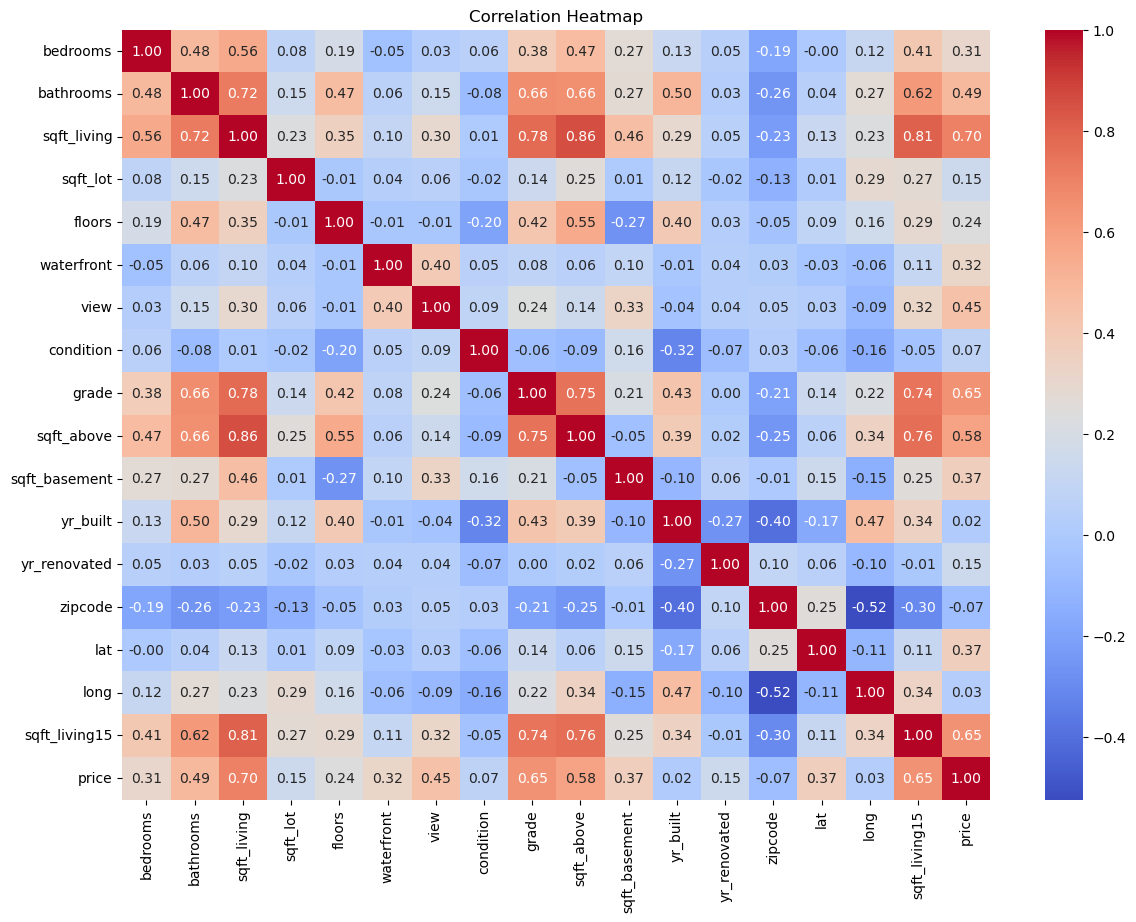

In [12]:
import seaborn as sns

corr_matrix = df.corr(numeric_only = True)

plt.figure(figsize = (14, 10))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
X = df.drop(columns = 'price')
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [22]:
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [23]:
print(model.coef_)
print(model.intercept_)

[-1.56160970e+00  1.98202739e+00  8.75464208e-03 -2.70716881e-06
  1.32205297e+00  7.30296641e+01  5.43792735e+00  1.86936231e+00
  7.52161149e+00  3.85954174e-03  4.89510033e-03 -2.46981968e-01
  6.21476896e-03 -4.18375889e-02  6.11534603e+01 -7.09945572e+00
  7.58399522e-03]
758.0324268843481


In [24]:
y_pred = model.predict(x_test)

## Evaluation

In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(r2)

10.756451641640565
294.31757947841237
0.6726302580255301


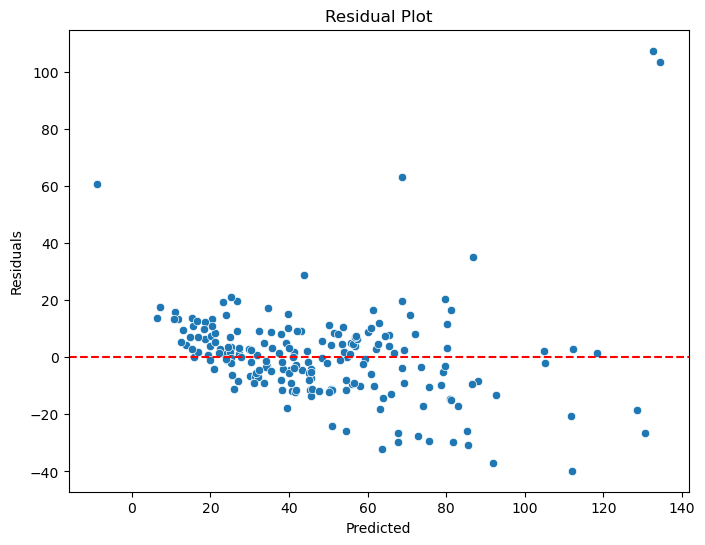

In [28]:
residuals = y_test - y_pred

plt.figure(figsize = (8, 6))

sns.scatterplot(x = y_pred, y = residuals)

plt.axhline(0, color = "red", linestyle = '--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()